In [1]:
%load_ext autoreload
%autoreload 2

In [3]:

from pathlib import Path
import random

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import  DataLoader
import torchvision.models as models
import torchvision.transforms as T

from torchinfo import summary

from tqdm import tqdm


import utils
from dataset import ImageDataset

torch.backends.cudnn.benchmark = True

# Params

In [4]:
CLASSES = ['Healthy', 'OC Degeneration']

load_checkpoints = True

modeltype = 'resnet18'

ds = 'simple/bend_only'

# Setup and Load Datasets

In [5]:
relative_model_path = "two4two_sickones_models_pytorch"
base_path = Path('./') / relative_model_path
base_path

imp_features = ['ill_chars', 'main_spherical', 'sec_spherical', 'sphere_diff', 'num_diff', 'bending', 'arm_position', 'obj_color', 'bg_color']


## Load Dataset and Dataloaders


In [10]:
# path is new dataset with simple/bend_only dataset variation
data_dir = utils.download_file(url="https://uni-bielefeld.sciebo.de/s/7LRzXGh2EGpb7nX/download",
                               file_name="blockies_datasets.tar.gz",
                               cache_dir='./data', # change this if needed
                               extract=True,
                               force_download=False,
                               archive_folder='blockies_datasets')


ds_dir = data_dir / ds
ds_dir

File already exists at: data/blockies_datasets.tar.gz
File extracted to: ./data


PosixPath('data/blockies_datasets/simple/bend_only')

In [11]:
runstats = False

if runstats:
  train_df = utils.load_dataframe(ds_dir, 'train')
  train_transforms = T.Compose([
      T.ToTensor()
  ])
  train_dataset = ImageDataset(train_df, ds_dir / 'train', transform=train_transforms)
  dataloader = DataLoader(train_dataset, batch_size=100, shuffle=True,
                          num_workers=6, pin_memory=True)

  # Initialize variables to calculate mean
  mean = torch.zeros(3)  # For RGB channels
  total_pixels = 0

  # Loop through the dataset
  for data in tqdm(dataloader):
      images = data[0]
      # Sum pixel values per channel
      mean += images.sum(dim=[0, 2, 3])
      total_pixels += images.size(0) * images.size(2) * images.size(3)

  # Divide by total number of pixels
  mean /= total_pixels

  # Initialize variables for std calculation
  std = torch.zeros(3)

  # Loop again for standard deviation
  for data in tqdm(dataloader):
      images = data[0]
      std += ((images - mean.view(1, 3, 1, 1))**2).sum(dim=[0, 2, 3])

  std = torch.sqrt(std / total_pixels)

else:
  # Hardcoded meand and std values
  if ds == 'simple/bend_only':
    # These are the mean and std values for the simple/bend_only dataset
    mean = torch.tensor([0.8273, 0.8057, 0.8174])
    std = torch.tensor([0.0740, 0.0805, 0.0879])
  elif ds == 'sick_ones_bendbias_v3_2class_normal':
    # these are from the original "normal" dataset
    mean = torch.tensor([0.8068, 0.7830, 0.8005])
    std = torch.tensor([0.1093, 0.1136, 0.1029])
  else:
    raise ValueError("Dataset not recognized for hardcoded mean/std values.")
   
print(f"Mean per channel: {mean}")
print(f"Standard Deviation per channel: {std}")

Mean per channel: tensor([0.8273, 0.8057, 0.8174])
Standard Deviation per channel: tensor([0.0740, 0.0805, 0.0879])


In [12]:
def preprocess_exp_df(df):
    '''
    Preprocess the experimental DataFrame for experiments with bending only dataset.
    This function updates the blocky state (ocd or healthy) based on the bending feature.
    It also calculates the difference between main and secondary spherical features, to
    better review the difference in spherical features between the two sets of bones

    Parameters:
    df (pd.DataFrame): The DataFrame containing experimental data with bending feature. 

    Returns:
    pd.DataFrame: The updated DataFrame with updated object name, illness status,
                   and spherical differences.
    '''

    df.loc[df['bending'] > 0.2, 'obj_name'] = 'ocd'
    df.loc[df['bending'] <= 0.2, 'obj_name'] = 'healthy'
    df['ill'] = (df['obj_name'] == 'ocd').astype(int)
    df['sphere_diff'] = (df.main_spherical - df.sec_spherical).abs()
    return df

In [13]:
train_df = utils.load_dataframe(ds_dir, 'train')
val_df = utils.load_dataframe(ds_dir, 'validation')
test_df = utils.load_dataframe(ds_dir, 'test')
xai_df = utils.load_dataframe(ds_dir, 'xai')
xai_exp_df = preprocess_exp_df(utils.load_dataframe(ds_dir, 'xai_experimental'))  # dataset with progressive bending examples

len(train_df), len(val_df), len(test_df), len(xai_df), len(xai_exp_df)

(20000, 1000, 2000, 100, 1100)

In [29]:
train_df.columns

Index(['obj_name', 'labeling_error', 'spherical', 'bending',
       'obj_rotation_roll', 'obj_rotation_pitch', 'obj_rotation_yaw', 'fliplr',
       'position_x', 'position_y', 'arm_position', 'obj_color',
       'obj_color_rgba', 'bg_color', 'bg_color_rgba', 'resolution',
       'ill_spherical', 'num_diff', 'id', 'original_id', '_attributes_status',
       'num_ill_chars', 'ill_chars', 'main_spherical', 'sec_spherical',
       'num_sec_bones', 'label', '__module__', '__name__', 'filename', 'ill'],
      dtype='object')

In [44]:
import pandas as pd

pd.set_option('display.max_columns', None)

train_df.head(2)

,obj_name,labeling_error,spherical,bending,obj_rotation_roll,obj_rotation_pitch,obj_rotation_yaw,fliplr,position_x,position_y,arm_position,obj_color,obj_color_rgba,bg_color,bg_color_rgba,resolution,ill_spherical,num_diff,id,original_id,_attributes_status,num_ill_chars,ill_chars,main_spherical,sec_spherical,num_sec_bones,label,__module__,__name__,filename,ill
0,ocd,False,0.5,0.325053,-0.015708,-0.003318,-0.998716,False,-0.769852,-0.175491,0.224143,0.816669,"[0.918281672584313, 0.48417347218039203, 0.377...",0.795180,"[0.9343054549058821, 0.5259175116549021, 0.412...","[256, 256]",0.5,1,aec337e8-c30a-4de6-940a-23947b132147,NaN,"{'obj_name': 'sampled', 'num_ill_chars': 'samp...",1,[high_bend],0.741900,0.116562,2,ocd,blockies.blocky_scene_parameters,BlockySceneParameters,aec337e8-c30a-4de6-940a-23947b132147.png,1
1,healthy,False,0.5,0.178033,-0.012607,0.217708,-1.934799,False,-0.301570,-0.498295,0.415535,0.350672,"[0.6881884831921561, 0.793178379298039, 0.9880...",0.249405,"[0.5488761722823521, 0.6851035851764701, 0.994...","[256, 256]",0.5,1,674490c9-d216-403d-81bf-892f740979bb,NaN,"{'obj_name': 'sampled', 'num_ill_chars': 'samp...",0,[],0.079699,0.747116,1,healthy,blockies.blocky_scene_parameters,BlockySceneParameters,674490c9-d216-403d-81bf-892f740979bb.png,0


count    20000.000000
mean         0.190979
std          0.102660
min          0.000011
25%          0.101166
50%          0.201625
75%          0.278847
max          0.389769
Name: bending, dtype: float64

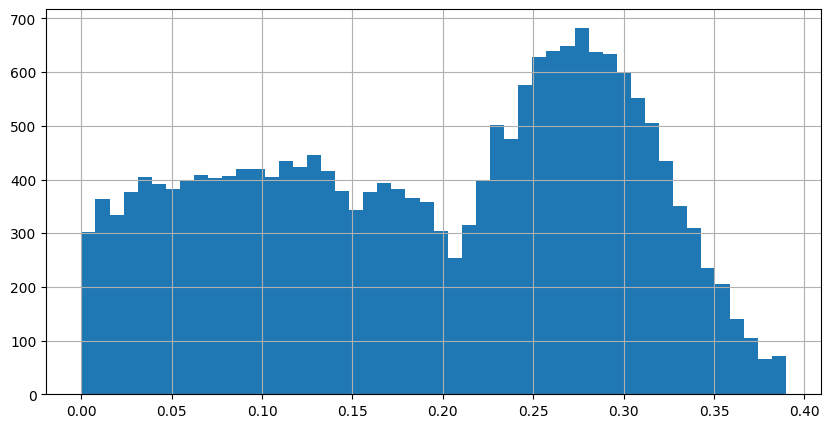

In [52]:
train_df.bending.hist(bins=50, figsize=(10, 5))
train_df.bending.describe()

In [14]:
transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=mean, std=std)
])

In [15]:
# num_workers = 0  # set to 0 for debugging, increase if needed for performance
num_workers = 6  # for production, increase to speed up data loading

train_dataset = ImageDataset(train_df, ds_dir / 'train', transform=transform)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=False,    # not training so shuffle=False
                              num_workers=num_workers, pin_memory=True)

train_eval_dataset = ImageDataset(train_df, ds_dir / 'train', transform=transform)
train_eval_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=False,
                                   num_workers=num_workers, pin_memory=True)

val_dataset = ImageDataset(val_df,  ds_dir / 'validation', transform=transform)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False,
                            num_workers=num_workers, pin_memory=True)

test_dataset = ImageDataset(test_df,  ds_dir / 'test', transform=transform)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False,
                             num_workers=num_workers, pin_memory=True)

xai_dataset = ImageDataset(xai_df,  ds_dir / 'xai', transform=transform)
xai_dataloader = DataLoader(xai_dataset, batch_size=32, shuffle=False,
                            num_workers=num_workers, pin_memory=True)

xai_exp_dataset = ImageDataset(xai_exp_df,  ds_dir / 'xai_experimental', transform=transform)
xai_exp_dataloader = DataLoader(xai_exp_dataset, batch_size=32, shuffle=False,
                                 num_workers=num_workers, pin_memory=True)

len(train_dataset), len(val_dataset), len(test_dataset), len(xai_dataset), len(xai_exp_dataset)

(20000, 1000, 2000, 100, 1100)

In [16]:
data_ex = next(iter(train_dataloader))

In [17]:
# sanity check on the data 
print("Input Image:", data_ex[0].shape) 
print("Labels", data_ex[1].shape)
print("Blocky IDs:", len(data_ex[2]))
print("Example ID:", data_ex[2][0])

Input Image: torch.Size([32, 3, 256, 256])
Labels torch.Size([32])
Blocky IDs: 32
Example ID: aec337e8-c30a-4de6-940a-23947b132147


# Model Loading

In [18]:
def set_seed(seed):
  """
  Sets random seeds for reproducibility.
  """
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False


def evaluate_model(model, dataloader, criterion, device):
    model.eval()  # Set model to evaluation mode
    running_loss = 0.0
    correct = 0
    total = 0

    preds = []
    with torch.no_grad():  # Disable gradient calculation
        for data in tqdm(dataloader):
            inputs, labels = data[0], data[1]
            inputs, labels = inputs.to(device), labels.to(device)

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Track loss and accuracy
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            preds.extend(predicted.cpu().numpy())
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    avg_loss = running_loss / len(dataloader)
    accuracy = correct / total

    print(f"Evaluation Loss: {avg_loss:.4f}, Evaluation Accuracy: {accuracy:.4f}")
    return avg_loss, accuracy, np.array(preds)

In [19]:
def load_resnet18(num_classes, pretrained=True, checkpoint_path=None):
  model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT if pretrained else None)
  model.fc = nn.Linear(model.fc.in_features, num_classes)

  if checkpoint_path:
      checkpoint = torch.load(checkpoint_path, map_location='cpu')
      model.load_state_dict(checkpoint)
      print(f"Loaded checkpoint from: {checkpoint_path}")

  return model

In [20]:
def load_resnet50(num_classes, pretrained=True, checkpoint_path=None):
    """Loads a ResNet-50 model, optionally loading from a checkpoint.

    Args:
      num_classes: Number of output classes.
      pretrained: Whether to load pretrained weights.
      checkpoint_path: Path to a checkpoint file to load.

    Returns:
      A ResNet-50 model.
    """
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT if pretrained else None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)  # Replace final fully-connected layer

    if checkpoint_path:
        checkpoint = torch.load(checkpoint_path, map_location='cpu')
        model.load_state_dict(checkpoint)
        print(f"Loaded checkpoint from: {checkpoint_path}")

    return model


In [21]:
# setup checkpoint folders
checkpoint_path = Path('checkpoints/simple/bend_only/resnet18')
(checkpoint_path / 'tmp').mkdir(parents=True, exist_ok=True)
(checkpoint_path / 'final').mkdir(parents=True, exist_ok=True)

In [22]:
# Define loss function
criterion = nn.CrossEntropyLoss()
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [23]:
# load best model and evaluate

model = load_resnet18(num_classes=len(CLASSES),
                         pretrained=False,
                         checkpoint_path=checkpoint_path / 'final' / 'best_model.pth')
model.to(device)
model.eval();  # Set model to evaluation mode

Loaded checkpoint from: checkpoints/simple/bend_only/resnet18/final/best_model.pth


In [24]:
summary(model, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 2]                    --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 64, 56, 56]           --
│    └─BasicBlock: 2-1                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-6                    [1, 64, 56, 56]           --
│

In [25]:
# load model predications for test and xai datasets (all results should be close to 1.0)
_, _, test_preds = evaluate_model(model, test_dataloader, criterion, device)
_, _, xai_preds = evaluate_model(model, xai_dataloader, criterion, device)
_, _, xai_exp_preds = evaluate_model(model, xai_exp_dataloader, criterion, device)

# add predictions to the respective DataFrames
test_df['preds'] = test_preds
xai_df['preds'] = xai_preds
xai_exp_df['preds'] = xai_exp_preds

100%|██████████| 63/63 [00:06<00:00, 10.35it/s]


Evaluation Loss: 0.0395, Evaluation Accuracy: 0.9830


100%|██████████| 4/4 [00:01<00:00,  3.42it/s]


Evaluation Loss: 0.0059, Evaluation Accuracy: 1.0000


100%|██████████| 35/35 [00:02<00:00, 12.34it/s]

Evaluation Loss: 0.0200, Evaluation Accuracy: 0.9964


In [26]:
# sanity check to ensure predictions saved to dataframes correctly
test_acc = (test_df['preds'] == test_df['ill'].astype(int)).sum() / len(test_df)
xai_acc = (xai_df['preds'] == xai_df['ill'].astype(int)).sum() / len(xai_df)
xai_exp_acc = (xai_exp_df['preds'] == xai_exp_df['ill'].astype(int)).sum() / len(xai_exp_df)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"XAI Accuracy: {xai_acc:.4f}")
print(f"XAI Experimental Accuracy: {xai_exp_acc:.4f}") # need to update the true labels for the experimental dataset (samples 6-10 are ill)

Test Accuracy: 0.9830
XAI Accuracy: 1.0000
XAI Experimental Accuracy: 0.9964


# Review Dataset

Review the distributions of various features in the dataset, for the current dataset only the *bending* feature should have different distributions for ill or not ill classes.

In [28]:
xai_df

,obj_name,labeling_error,spherical,bending,obj_rotation_roll,obj_rotation_pitch,obj_rotation_yaw,fliplr,position_x,position_y,...,ill_chars,main_spherical,sec_spherical,num_sec_bones,label,__module__,__name__,filename,ill,preds
0,healthy,False,0.5,0.030469,-0.016637,-0.047094,-2.267247,False,-0.439530,-0.556088,...,[],0.998686,0.449897,3,healthy,blockies.blocky_scene_parameters,BlockySceneParameters,4f2eb696-b8d9-4fe2-9104-710ad5da29bb.png,0,0
1,ocd,False,0.5,0.271484,0.011829,-0.144891,-0.817337,False,-0.424032,-0.241520,...,[high_bend],0.989917,0.378825,2,ocd,blockies.blocky_scene_parameters,BlockySceneParameters,893265c4-ce12-4a01-b6d6-198b7232f851.png,1,1
2,healthy,False,0.5,0.156136,-0.050532,0.401999,-2.338776,False,-0.075487,-0.522321,...,[],0.748230,0.169283,2,healthy,blockies.blocky_scene_parameters,BlockySceneParameters,398cb372-6701-430f-8912-109afef754d6.png,0,0
3,healthy,False,0.5,0.040581,-0.035582,-0.131209,-2.802431,False,-0.636283,-0.355255,...,[],0.052703,0.648142,1,healthy,blockies.blocky_scene_parameters,BlockySceneParameters,74acbffb-bcf1-4da0-98fb-524f4bad19c5.png,0,0
4,ocd,False,0.5,0.289963,0.022550,0.003450,-3.114582,False,-0.677988,-0.705393,...,[high_bend],0.000180,0.603095,1,ocd,blockies.blocky_scene_parameters,BlockySceneParameters,ccebc79a-385c-4c60-8bed-032a6e75d8e4.png,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,healthy,False,0.5,0.025592,-0.004622,0.194251,-2.765237,False,-0.111338,-0.423802,...,[],0.612836,0.029339,1,healthy,blockies.blocky_scene_parameters,BlockySceneParameters,93923873-1c7a-474b-b2bb-dd8ab53ed25c.png,0,0
96,healthy,False,0.5,0.094209,-0.021815,0.055097,-1.415880,False,-0.398351,-0.608288,...,[],0.941186,0.347641,3,healthy,blockies.blocky_scene_parameters,BlockySceneParameters,8277a633-9714-4d37-ac90-d307e6cbbc63.png,0,0
97,ocd,False,0.5,0.276860,-0.031321,0.062545,-0.504173,False,-0.187735,-0.504239,...,[high_bend],0.102123,0.731462,3,ocd,blockies.blocky_scene_parameters,BlockySceneParameters,d89a8e16-9746-4165-b685-7d345328a7f2.png,1,1
98,ocd,False,0.5,0.260591,-0.021831,0.106122,-0.954519,False,-0.371296,-0.719213,...,[high_bend],0.359082,0.942252,1,ocd,blockies.blocky_scene_parameters,BlockySceneParameters,704fb36a-b656-4d79-987f-86af12caea5d.png,1,1


<Axes: xlabel='bending', ylabel='Count'>

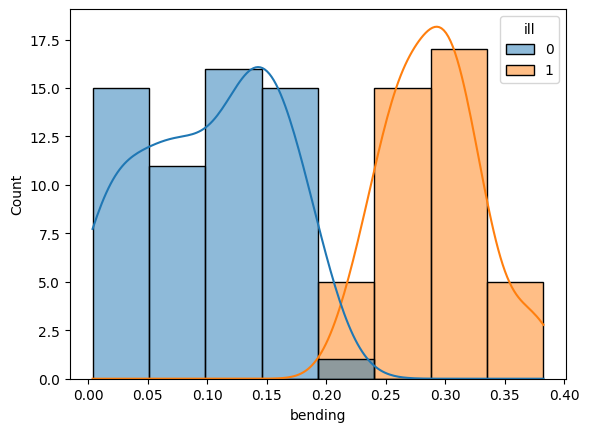

In [27]:
sns.histplot(data=xai_df, x='bending', hue='ill', kde=True)

<Axes: xlabel='main_spherical', ylabel='Count'>

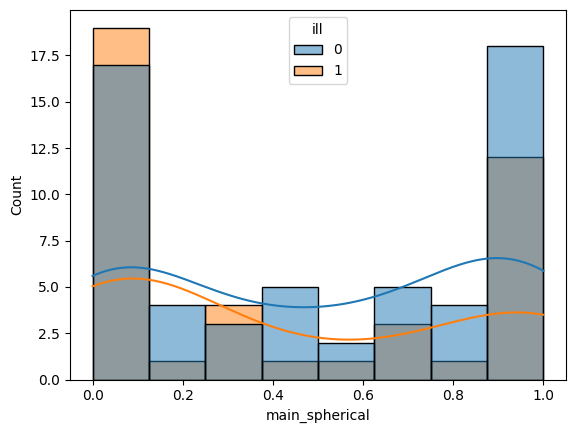

In [39]:
sns.histplot(data=xai_df, x='main_spherical', hue='ill', kde=True)

<Axes: xlabel='sec_spherical', ylabel='Count'>

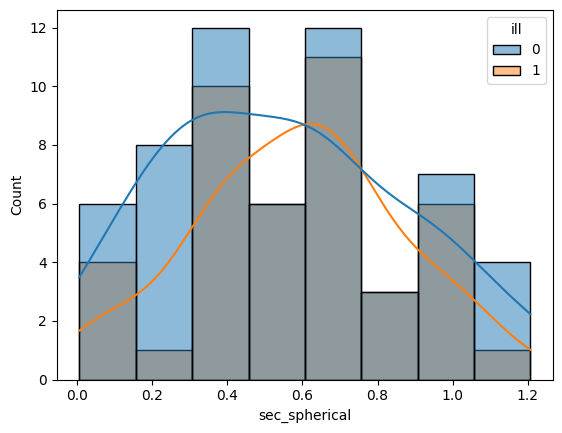

In [40]:
sns.histplot(data=xai_df, x='sec_spherical', hue='ill', kde=True)

<Axes: xlabel='arm_position', ylabel='Count'>

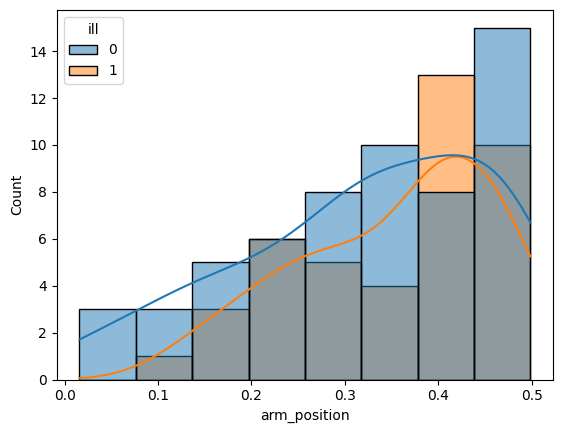

In [41]:
sns.histplot(data=xai_df, x='arm_position', hue='ill', kde=True)

In [58]:
xai_df.bending.describe()

count    100.000000
mean       0.180880
std        0.105906
min        0.003772
25%        0.091772
50%        0.168957
75%        0.277852
max        0.382453
Name: bending, dtype: float64

In [47]:
xai_df[xai_df['ill'] != xai_df['preds']].head()  # show misclassified samples

,obj_name,labeling_error,spherical,bending,obj_rotation_roll,obj_rotation_pitch,obj_rotation_yaw,fliplr,position_x,position_y,arm_position,obj_color,obj_color_rgba,bg_color,bg_color_rgba,resolution,ill_spherical,num_diff,id,original_id,_attributes_status,num_ill_chars,ill_chars,main_spherical,sec_spherical,num_sec_bones,label,__module__,__name__,filename,ill,preds


We Focus on using XAI methods for the correct model classification, the True Positive (TP) and the True negative (TN).

## Visualize the Blockies

In [48]:
# sample ill and healthy images from the xai dataset for visualization
random_state = 27
notill_samples = xai_df[xai_df.ill == 0].sample(6, random_state=random_state)
paths = notill_samples.filename.apply(lambda x: ds_dir / 'xai' / x)
notill_imgs = utils.load_imgs(paths)
ill_samples = xai_df[xai_df.ill == 1].sample(6, random_state=random_state)
paths = ill_samples.filename.apply(lambda x: ds_dir / 'xai' / x)
ill_imgs = utils.load_imgs(paths)

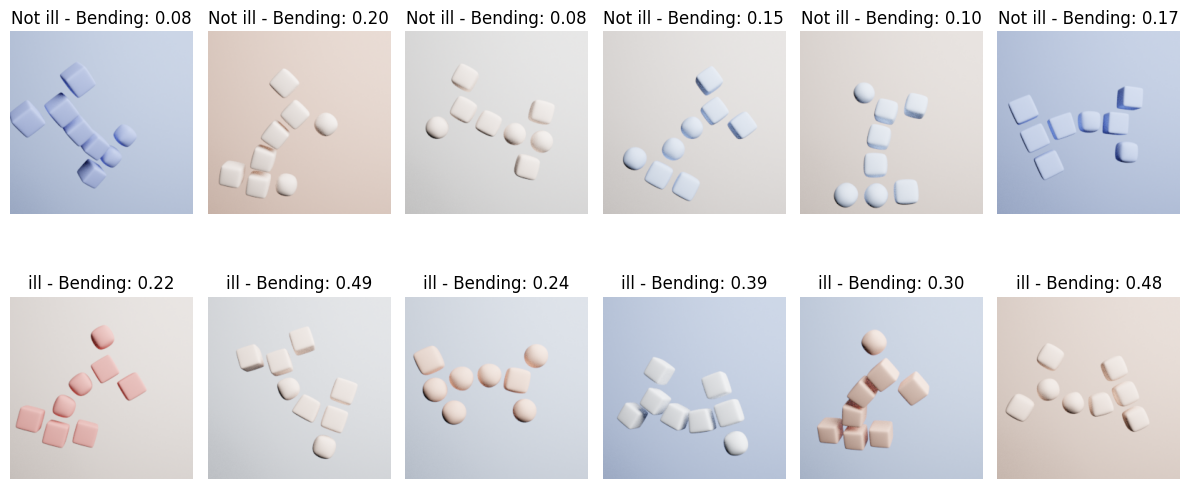

In [50]:
# visualize the sampled images

axes = plt.subplots(2, 6, figsize=(12, 6))[1]
for i, img in enumerate(notill_imgs):
    axes[0, i].imshow(img)
    axes[0, i].axis('off')
    axes[0, i].set_title(f'Not ill - Bending: {notill_samples.iloc[i].bending:.2f}')
for i, img in enumerate(ill_imgs):
    axes[1, i].imshow(img)
    axes[1, i].axis('off')
    axes[1, i].set_title(f'ill - Bending: {ill_samples.iloc[i].arm_position:.2f}')
plt.tight_layout()
plt.show()

## Visualize the Experimental Dataset

Here we view an example of the progression of the single bending feature for the same blocky. 

The bend threshold for this example is 0.2, below that the blockies are *healthy* and above that they are *ill*

In [49]:
# sample a blocky from the main xai dataset
bid = xai_df.sample(1, random_state=random_state).id.values[0]
print(f"Blocky ID: {bid}")

Blocky ID: 5fffb03c-f204-4f41-8740-0cde4f0b2a44


In [70]:
# load the corresponding set of blockies (features and images) from the experimental dataset
# these are the bending examples with progressive bending

xai_exp_subset = utils.get_progressive_blockies(bid, xai_exp_df, feature_name='bending')
paths = xai_exp_subset.filename.apply(lambda x: ds_dir / 'xai_experimental' / x)
xai_exp_imgs = utils.load_imgs(paths)

xai_exp_subset

,obj_name,labeling_error,spherical,bending,obj_rotation_roll,obj_rotation_pitch,obj_rotation_yaw,fliplr,position_x,position_y,...,main_spherical,sec_spherical,num_sec_bones,label,__module__,__name__,filename,ill,sphere_diff,preds
980,healthy,False,0.5,0.000000,-0.021691,-0.208508,-1.436231,False,-0.789119,-0.691531,...,1.817000e-07,0.534897,2,ocd,blockies.blocky_scene_parameters,BlockySceneParameters,5fffb03c-f204-4f41-8740-0cde4f0b2a44_bending_1...,0,0.534897,0
981,healthy,False,0.5,0.044444,-0.021691,-0.208508,-1.436231,False,-0.789119,-0.691531,...,1.817000e-07,0.534897,2,ocd,blockies.blocky_scene_parameters,BlockySceneParameters,5fffb03c-f204-4f41-8740-0cde4f0b2a44_bending_2...,0,0.534897,0
982,healthy,False,0.5,0.088889,-0.021691,-0.208508,-1.436231,False,-0.789119,-0.691531,...,1.817000e-07,0.534897,2,ocd,blockies.blocky_scene_parameters,BlockySceneParameters,5fffb03c-f204-4f41-8740-0cde4f0b2a44_bending_3...,0,0.534897,0
983,healthy,False,0.5,0.133333,-0.021691,-0.208508,-1.436231,False,-0.789119,-0.691531,...,1.817000e-07,0.534897,2,ocd,blockies.blocky_scene_parameters,BlockySceneParameters,5fffb03c-f204-4f41-8740-0cde4f0b2a44_bending_4...,0,0.534897,0
984,healthy,False,0.5,0.177778,-0.021691,-0.208508,-1.436231,False,-0.789119,-0.691531,...,1.817000e-07,0.534897,2,ocd,blockies.blocky_scene_parameters,BlockySceneParameters,5fffb03c-f204-4f41-8740-0cde4f0b2a44_bending_5...,0,0.534897,0
985,ocd,False,0.5,0.222222,-0.021691,-0.208508,-1.436231,False,-0.789119,-0.691531,...,1.817000e-07,0.534897,2,ocd,blockies.blocky_scene_parameters,BlockySceneParameters,5fffb03c-f204-4f41-8740-0cde4f0b2a44_bending_6...,1,0.534897,1
986,ocd,False,0.5,0.266667,-0.021691,-0.208508,-1.436231,False,-0.789119,-0.691531,...,1.817000e-07,0.534897,2,ocd,blockies.blocky_scene_parameters,BlockySceneParameters,5fffb03c-f204-4f41-8740-0cde4f0b2a44_bending_7...,1,0.534897,1
987,ocd,False,0.5,0.311111,-0.021691,-0.208508,-1.436231,False,-0.789119,-0.691531,...,1.817000e-07,0.534897,2,ocd,blockies.blocky_scene_parameters,BlockySceneParameters,5fffb03c-f204-4f41-8740-0cde4f0b2a44_bending_8...,1,0.534897,1
988,ocd,False,0.5,0.355556,-0.021691,-0.208508,-1.436231,False,-0.789119,-0.691531,...,1.817000e-07,0.534897,2,ocd,blockies.blocky_scene_parameters,BlockySceneParameters,5fffb03c-f204-4f41-8740-0cde4f0b2a44_bending_9...,1,0.534897,1
989,ocd,False,0.5,0.400000,-0.021691,-0.208508,-1.436231,False,-0.789119,-0.691531,...,1.817000e-07,0.534897,2,ocd,blockies.blocky_scene_parameters,BlockySceneParameters,5fffb03c-f204-4f41-8740-0cde4f0b2a44_bending_1...,1,0.534897,1


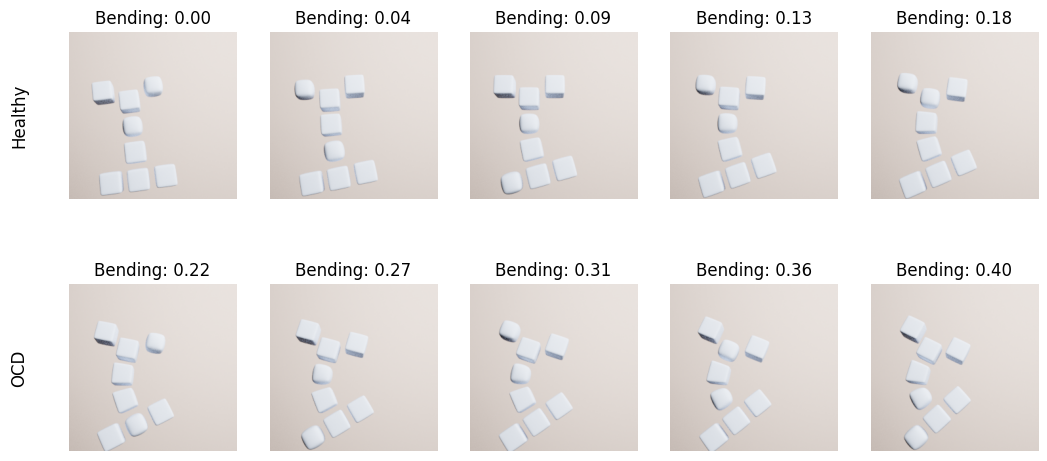

In [71]:
# bend threshold is 0.2 for determining ill samples
axes = plt.subplots(2, 5, figsize=(12.5, 6))[1]
for i, ((idx, row), img, ax) in enumerate(zip(xai_exp_subset.iterrows(), xai_exp_imgs, axes.flatten())):
    if i == 0:
        ax.text(-0.3, 0.5, 'Healthy', va='center', ha='center', rotation='vertical', fontsize=12, transform=ax.transAxes)
    elif i == 5:
        ax.text(-0.3, 0.5, 'OCD', va='center', ha='center', rotation='vertical', fontsize=12, transform=ax.transAxes)

    ax.imshow(img)

    ax.axis('off')
    ax.set_title(f'Bending: {row.bending:.2f}')
